# Q-Learning – Learner Notebook

## Reinforcement Learning Lab

### Learning Objectives

By the end of this notebook, you will be able to:

- Explain the basic idea of Q-Learning.
- Identify the state space, action space, reward and Q-table of an environment.
- Implement an epsilon-greedy action-selection policy.
- Update Q-values using the Q-Learning update rule.
- Train an agent in the FrozenLake environment.
- Evaluate the learned policy.
- Visualize and interpret the learned Q-table and the agent's path.

> **Learner focus:** Complete the marked learner activities before running the corresponding solution cells.


## Before You Start

Q-Learning is a **model-free reinforcement learning algorithm**. The agent learns the value of taking an action in a state by interacting directly with the environment.

The learner does not need to know the transition model of the environment in advance. Instead, it repeatedly:

1. observes the current state,
2. selects an action,
3. receives a reward and the next state,
4. updates the Q-value,
5. continues until the episode ends.

In this notebook, we use **FrozenLake** as a small grid-world environment so that the learning process can be inspected easily.


## 1. Install and Import Dependencies

We use `gymnasium` for the reinforcement learning environment, NumPy for the Q-table, and Matplotlib for simple visualization.


In [34]:
%pip install gymnasium



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [35]:
import numpy as np
import random
import matplotlib.pyplot as plt
import gymnasium as gym

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Create the FrozenLake Environment

FrozenLake is a grid-world problem.

The standard 4 × 4 map contains:

- **S** – Start
- **F** – Frozen surface
- **H** – Hole
- **G** – Goal

The agent must move from the starting position to the goal without falling into a hole.

We initially use `is_slippery=False` so that the effect of Q-Learning is easier to understand.


In [36]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False
)

print("Environment created successfully.")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)


Environment created successfully.
Observation space: Discrete(16)
Action space: Discrete(4)


## 3. Understand the Environment

The environment provides two important spaces:

### Observation Space

The observation represents the current **state** of the agent.

For the 4 × 4 FrozenLake environment, there are 16 possible states.

### Action Space

The agent can perform four actions:

- **0** – Move Left
- **1** – Move Down
- **2** – Move Right
- **3** – Move Up

### Learner Activity 1

Run the next cell and answer:

1. How many states are present?
2. How many actions can the agent perform?
3. What does one state represent in this environment?


In [37]:
print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

action_names = {
    0: "Left",
    1: "Down",
    2: "Right",
    3: "Up"
}

print("\nActions:")
for action, name in action_names.items():
    print(action, "->", name)


Number of states: 16
Number of actions: 4

Actions:
0 -> Left
1 -> Down
2 -> Right
3 -> Up


## 4. Inspect a Single Interaction

An episode begins by resetting the environment.

The agent then selects an action. The environment returns:

- the next state,
- the reward,
- whether the episode has terminated,
- whether the episode has been truncated,
- additional information.

This interaction is the basis of reinforcement learning.


In [38]:
state, info = env.reset(seed=42)

print("Initial state:", state)

action = env.action_space.sample()
next_state, reward, terminated, truncated, info = env.step(action)

print("Action:", action_names[action])
print("Next state:", next_state)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)


Initial state: 0
Action: Up
Next state: 0
Reward: 0
Terminated: False
Truncated: False


## 5. The Q-Table

Q-Learning stores what the agent has learned in a **Q-table**.

Each row represents a state and each column represents an action.

For the 4 × 4 FrozenLake environment:

- rows = 16 states
- columns = 4 actions

Therefore, the Q-table has **16 × 4 entries**.

Initially, the agent has no knowledge about which action is useful, so the Q-values can be initialized to zero.


In [39]:
state_space = env.observation_space.n
action_space = env.action_space.n

Q_table = np.zeros((state_space, action_space))

print("Q-table shape:", Q_table.shape)
print(Q_table)


Q-table shape: (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### Learner Activity 2 – Initialize the Q-Table

Complete the function below.

**Task:** Create and return a NumPy array containing zeros with:

- number of rows = state space
- number of columns = action space


In [40]:
def initialize_q_table(state_space, action_space):
    Q_table = np.zeros((state_space, action_space))
    return Q_table

# Test the function
Q_table = initialize_q_table(state_space, action_space)

print("Q-table shape:", Q_table.shape)
print(Q_table)

Q-table shape: (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## 6. Exploration and Exploitation

A reinforcement learning agent has two competing choices:

### Exploration

The agent tries different actions to discover potentially useful actions.

### Exploitation

The agent chooses the action that currently has the highest learned Q-value.

We use an **epsilon-greedy policy** to balance these two behaviours.

If epsilon is high, the agent explores more.

If epsilon is low, the agent exploits the learned Q-values more often.


## 7. Epsilon-Greedy Policy

The policy follows this idea:

- Generate a random value between 0 and 1.
- If the value is less than epsilon, select a random action.
- Otherwise, select the action with the highest Q-value.

This allows the agent to explore early in training and gradually exploit what it has learned.


### Learner Activity 3 – Implement Epsilon-Greedy Policy

Complete the function.

**Hint:** Use `random.uniform()` and `np.argmax()`.

Do not remove the comments; use them to understand each step.


In [41]:
def epsilon_greedy_policy(Q_table, state, epsilon):

    # Generate a random number between 0 and 1
    random_number = random.uniform(0, 1)

    # Exploration
    if random_number < epsilon:
        action = env.action_space.sample()

    # Exploitation
    else:
        action = np.argmax(Q_table[state])

    return action

## 8. Greedy Policy

After training, we normally want the agent to exploit its learned knowledge.

A **greedy policy** always selects the action with the highest Q-value for the current state.


In [42]:
def greedy_policy(Q_table, state):
    action = np.argmax(Q_table[state])
    return action

print("Greedy policy function created.")


Greedy policy function created.


## 9. Q-Learning Update Rule

The central idea of Q-Learning is to improve the Q-value after every interaction.

The update can be expressed in words as:

**new Q-value equals old Q-value plus learning rate multiplied by the difference between the received reward plus discounted best future Q-value and the old Q-value.**

The components are:

- **Q-value** – current estimate for a state-action pair
- **learning rate** – controls how strongly new information changes the Q-value
- **reward** – immediate feedback from the environment
- **discount factor** – controls the importance of future rewards
- **maximum next Q-value** – the best estimated value available from the next state

For a terminal state, there is no future reward to consider, so the target is based only on the immediate reward.


## 10. Manual Q-Value Example

Consider:

- current Q-value = 0.20
- reward = 1
- learning rate = 0.5
- discount factor = 0.9
- maximum next-state Q-value = 0.80

### Learner Activity 4

Calculate the updated Q-value manually.

Write your calculation in the space below before checking your answer.

**Updated Q-value = ?**


In [43]:
# One possible manual calculation

old_q = 0.20
reward = 1.0
learning_rate = 0.5
discount_factor = 0.9
max_next_q = 0.80

target = reward + discount_factor * max_next_q
new_q = old_q + learning_rate * (target - old_q)

print("Target:", target)
print("Updated Q-value:", new_q)


Target: 1.7200000000000002
Updated Q-value: 0.9600000000000002


## 11. Training Hyperparameters

The following parameters control the learning process.

- **Number of episodes** – how many times the agent interacts with the environment
- **Maximum steps** – maximum number of actions in one episode
- **Learning rate** – how quickly the Q-table changes
- **Discount factor** – importance given to future rewards
- **Maximum epsilon** – initial exploration level
- **Minimum epsilon** – final exploration level
- **Epsilon decay rate** – controls how quickly exploration decreases


In [44]:
n_training_episodes = 5000
max_steps = 100

learning_rate = 0.7
discount_factor = 0.95

max_epsilon = 1.0
min_epsilon = 0.05
decay_rate = 0.001

print("Training parameters defined.")


Training parameters defined.


## 12. Train the Q-Learning Agent

During training, each episode follows this sequence:

1. Reset the environment.
2. Observe the current state.
3. Select an action using epsilon-greedy policy.
4. Perform the action.
5. Observe reward and next state.
6. Update the Q-table.
7. Move to the next state.
8. Repeat until the episode ends.
9. Reduce epsilon gradually.

### Learner Activity 5

Before running the training code, identify where the following operations occur:

- action selection
- environment interaction
- Q-value update
- epsilon decay


In [45]:
def train_q_learning(
    env,
    n_training_episodes,
    learning_rate,
    discount_factor,
    max_epsilon,
    min_epsilon,
    decay_rate,
    max_steps
):
    Q_table = np.zeros((env.observation_space.n, env.action_space.n))
    episode_rewards = []
    epsilon_history = []

    for episode in range(n_training_episodes):
        state, info = env.reset()
        total_reward = 0

        epsilon = min_epsilon + (
            max_epsilon - min_epsilon
        ) * np.exp(-decay_rate * episode)

        for step in range(max_steps):

            # Epsilon-greedy action selection
            action = epsilon_greedy_policy(Q_table, state, epsilon)

            # Take the action
            next_state, reward, terminated, truncated, info = env.step(action)

            # Q-Learning update
            best_next_q = np.max(Q_table[next_state])

            if terminated or truncated:
                target = reward
            else:
                target = reward + discount_factor * best_next_q

            Q_table[state, action] = Q_table[state, action] + learning_rate * (
                target - Q_table[state, action]
            )

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        episode_rewards.append(total_reward)
        epsilon_history.append(epsilon)

    return Q_table, episode_rewards, epsilon_history


## 13. Train the Agent

Run the following cell after completing the epsilon-greedy activity.

Training may take a short time because the agent interacts with the environment thousands of times.


In [46]:
Q_table, episode_rewards, epsilon_history = train_q_learning(
    env,
    n_training_episodes,
    learning_rate,
    discount_factor,
    max_epsilon,
    min_epsilon,
    decay_rate,
    max_steps
)

print("Training completed.")


Training completed.


## 14. Inspect the Learned Q-Table

The Q-table now contains the agent's learned estimates.

A higher Q-value indicates that the corresponding action is estimated to provide greater long-term return from that state.

The exact numerical values can vary depending on training settings and the environment.


In [47]:
np.set_printoptions(precision=3, suppress=True)

print("Learned Q-table:")
print(Q_table)


Learned Q-table:
[[0.735 0.774 0.774 0.735]
 [0.735 0.    0.815 0.774]
 [0.774 0.857 0.774 0.815]
 [0.815 0.    0.774 0.774]
 [0.774 0.815 0.    0.735]
 [0.    0.    0.    0.   ]
 [0.    0.902 0.    0.815]
 [0.    0.    0.    0.   ]
 [0.815 0.    0.857 0.774]
 [0.815 0.902 0.902 0.   ]
 [0.857 0.95  0.    0.857]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.902 0.95  0.857]
 [0.902 0.95  1.    0.902]
 [0.    0.    0.    0.   ]]


## 15. Extract the Learned Policy

For every state, select the action with the highest Q-value.

This converts the learned Q-table into a simple policy.


In [48]:
learned_policy = np.argmax(Q_table, axis=1)

print("State -> Best Action")
for state, action in enumerate(learned_policy):
    print(f"{state:2d} -> {action_names[action]}")


State -> Best Action
 0 -> Down
 1 -> Right
 2 -> Down
 3 -> Left
 4 -> Down
 5 -> Left
 6 -> Down
 7 -> Left
 8 -> Right
 9 -> Down
10 -> Down
11 -> Left
12 -> Left
13 -> Right
14 -> Right
15 -> Left


## 16. Evaluate the Trained Agent

Training and evaluation should be treated separately.

During training, exploration is allowed.

During evaluation, the agent uses the greedy policy and selects the action with the highest learned Q-value.


In [49]:
def evaluate_agent(env, Q_table, n_eval_episodes=100, max_steps=100):
    rewards = []

    for episode in range(n_eval_episodes):
        state, info = env.reset(seed=episode)
        total_reward = 0

        for step in range(max_steps):
            action = greedy_policy(Q_table, state)

            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        rewards.append(total_reward)

    return np.mean(rewards), np.std(rewards), rewards

mean_reward, std_reward, evaluation_rewards = evaluate_agent(
    env,
    Q_table,
    n_eval_episodes=100
)

print(f"Mean reward: {mean_reward:.2f}")
print(f"Standard deviation: {std_reward:.2f}")


Mean reward: 1.00
Standard deviation: 0.00


## 17. Visualize Learning Progress

The following graph shows the reward obtained during training.

Because individual episodes can be noisy, a moving average is also useful for observing the overall learning trend.


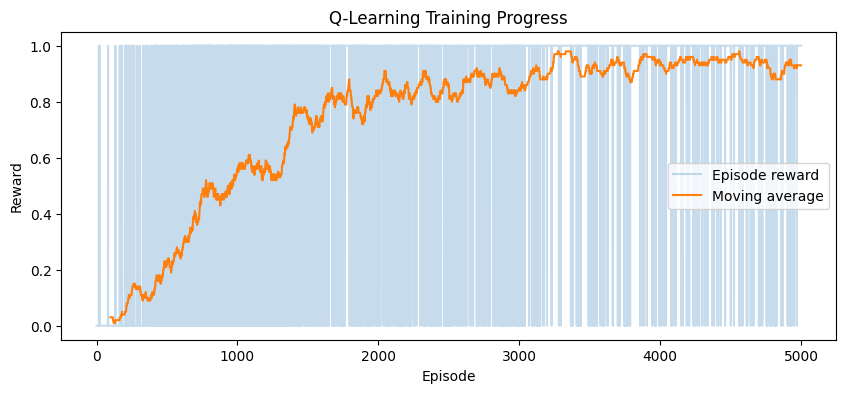

In [50]:
window = 100
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.25, label="Episode reward")
plt.plot(
    range(window - 1, len(episode_rewards)),
    moving_average,
    label="Moving average"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-Learning Training Progress")
plt.legend()
plt.show()


## 18. Visualize Epsilon Decay

Epsilon determines how much the agent explores.

At the beginning of training, epsilon is high.

As training progresses, epsilon decreases and the agent increasingly uses its learned Q-values.


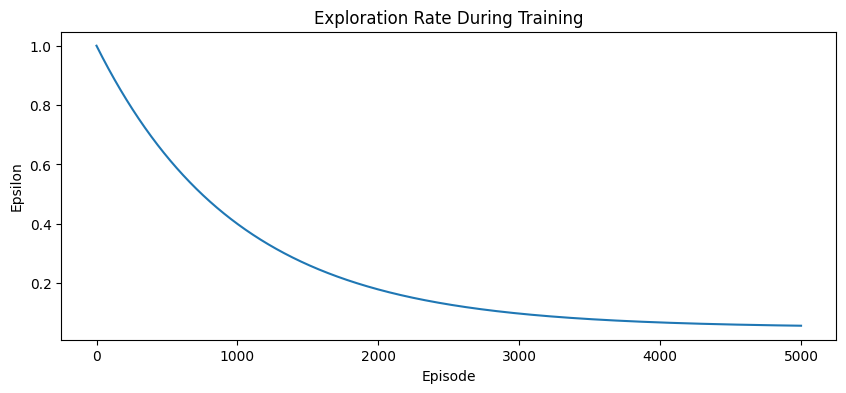

In [51]:
plt.figure(figsize=(10, 4))
plt.plot(epsilon_history)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Exploration Rate During Training")
plt.show()


## 19. Visualize the Q-Table

A heatmap makes it easier to inspect the relative Q-values of the available actions.

Rows correspond to states and columns correspond to actions.


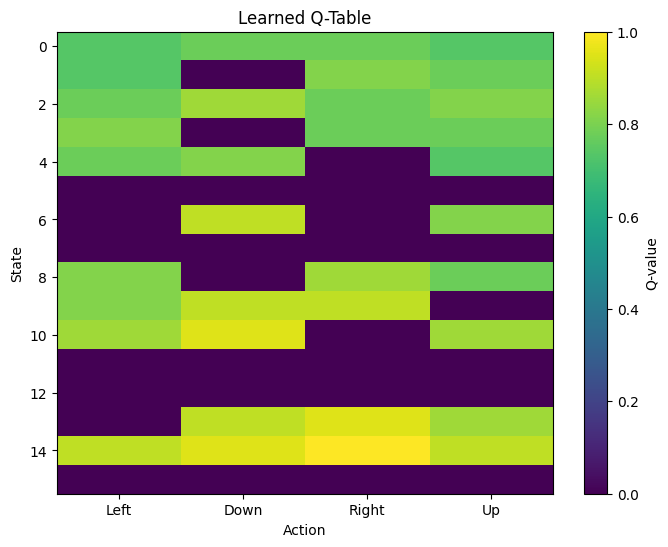

In [52]:
plt.figure(figsize=(8, 6))
plt.imshow(Q_table, aspect="auto")
plt.colorbar(label="Q-value")
plt.xticks(range(action_space), [action_names[i] for i in range(action_space)])
plt.xlabel("Action")
plt.ylabel("State")
plt.title("Learned Q-Table")
plt.show()


xThe heatmap shows the Q-values learned for each state-action pair. Brighter cells indicate higher Q-values and therefore more preferred actions, while darker cells indicate lower values. For each state, the action with the highest Q-value represents the action selected by the learned policy.

## 20. Animate the Trained Agent

The following section creates an **animated visualization** of the trained Q-Learning agent.

The animation shows:

- **Agent position** moving through the grid
- **Frozen cells**
- **Holes**
- **Goal**
- The **action selected at each step**
- The **current state**
- The **reward received**
- The final outcome of the episode

This is a visualization of the **learned greedy policy**. The agent selects the action with the highest Q-value at each state.

> **Note:** We use a separate environment with `render_mode="rgb_array"` for visualization. This does not change the Q-Learning algorithm or the learned Q-table.


In [53]:
%pip install -q "gymnasium[toy-text]"


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [54]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# Create a visualization environment.
animation_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="rgb_array"
)

def collect_episode_frames(env, Q_table, max_steps=100, seed=10):
    state, info = env.reset(seed=seed)

    frames = [env.render()]
    states = [state]
    actions = []
    rewards = []

    for step in range(max_steps):
        action = greedy_policy(Q_table, state)

        next_state, reward, terminated, truncated, info = env.step(action)

        frames.append(env.render())
        actions.append(action)
        rewards.append(reward)
        states.append(next_state)

        state = next_state

        if terminated or truncated:
            break

    return frames, states, actions, rewards

frames, states, actions, rewards = collect_episode_frames(
    animation_env,
    Q_table,
    max_steps=max_steps,
    seed=10
)

print("Number of frames:", len(frames))
print("States:", states)
print("Actions:", [action_names[a] for a in actions])
print("Rewards:", rewards)
print("Total reward:", sum(rewards))


Number of frames: 7
States: [0, 4, 8, 9, 13, 14, 15]
Actions: ['Down', 'Down', 'Right', 'Down', 'Right', 'Right']
Rewards: [0, 0, 0, 0, 0, 1]
Total reward: 1


### Animated Episode

Run the next cell to display the trained agent moving through FrozenLake.

The action shown in the title is the action taken **to reach the current frame**.


In [55]:
fig, ax = plt.subplots(figsize=(6, 6))

image = ax.imshow(frames[0])
ax.axis("off")

title = ax.set_title(
    f"Step 0 | State: {states[0]} | Start",
    fontsize=13,
    pad=12
)

def update(frame_number):
    image.set_data(frames[frame_number])

    if frame_number == 0:
        title.set_text(
            f"Step 0 | State: {states[0]} | Start"
        )
    else:
        action = actions[frame_number - 1]
        reward = rewards[frame_number - 1]

        if frame_number == len(frames) - 1:
            if reward == 1:
                status = "GOAL REACHED"
            else:
                status = "EPISODE ENDED"
        else:
            status = "Moving"

        title.set_text(
            f"Step {frame_number} | State: {states[frame_number]} | "
            f"Action: {action_names[action]} | Reward: {reward} | {status}"
        )

    return image, title

animation = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000,
    repeat=True
)

plt.close(fig)

# JavaScript animation works directly inside Google Colab/Jupyter.
display(HTML(animation.to_jshtml()))


### Action Legend

| Action Number | Action |
|---:|---|
| 0 | Left |
| 1 | Down |
| 2 | Right |
| 3 | Up |

The board itself shows the **agent, holes, frozen cells, and goal**. The animation title additionally reports the state, selected action, and reward at each step.


## 21. Learner Activity 6 – Experiment with Hyperparameters

Change **one parameter at a time** and repeat training.

Try:

1. Learning rate = 0.2
2. Learning rate = 0.9
3. Discount factor = 0.5
4. Discount factor = 0.99
5. Minimum epsilon = 0.01
6. Minimum epsilon = 0.20
7. Number of training episodes = 1000

For each experiment, record:

- mean evaluation reward
- standard deviation
- training behaviour
- whether the learned policy changes

### Question

Which parameter changes the learning behaviour most noticeably in your experiment?


In [56]:
# Learner Activity 6 - Hyperparameter Experiments

experiments = [
    ("Learning Rate", 0.2, "learning_rate"),
    ("Learning Rate", 0.9, "learning_rate"),
    ("Discount Factor", 0.5, "discount_factor"),
    ("Discount Factor", 0.99, "discount_factor"),
    ("Minimum Epsilon", 0.01, "min_epsilon"),
    ("Minimum Epsilon", 0.20, "min_epsilon"),
    ("Training Episodes", 1000, "episodes")
]

results = []

for parameter, value, parameter_type in experiments:

    # Keep the original values
    exp_learning_rate = learning_rate
    exp_discount_factor = discount_factor
    exp_min_epsilon = min_epsilon
    exp_episodes = n_training_episodes

    # Change only one parameter
    if parameter_type == "learning_rate":
        exp_learning_rate = value

    elif parameter_type == "discount_factor":
        exp_discount_factor = value

    elif parameter_type == "min_epsilon":
        exp_min_epsilon = value

    elif parameter_type == "episodes":
        exp_episodes = value

    # Train the agent
    experiment_Q, experiment_rewards, experiment_epsilon = train_q_learning(
        env,
        exp_episodes,
        exp_learning_rate,
        exp_discount_factor,
        max_epsilon,
        exp_min_epsilon,
        decay_rate,
        max_steps
    )

    # Evaluate the trained agent
    mean_reward, std_reward, evaluation_rewards = evaluate_agent(
        env,
        experiment_Q,
        n_eval_episodes=100,
        max_steps=max_steps
    )

    # Extract learned policy
    policy = np.argmax(experiment_Q, axis=1)

    results.append({
        "Parameter": parameter,
        "Value": value,
        "Mean Reward": mean_reward,
        "Std Dev": std_reward,
        "Policy": policy
    })

print("Hyperparameter Experiment Results\n")

for result in results:
    print(f"Parameter: {result['Parameter']}")
    print(f"Value: {result['Value']}")
    print(f"Mean Reward: {result['Mean Reward']:.3f}")
    print(f"Standard Deviation: {result['Std Dev']:.3f}")
    print(f"Learned Policy: {result['Policy']}")
    print("-" * 50)

Hyperparameter Experiment Results

Parameter: Learning Rate
Value: 0.2
Mean Reward: 1.000
Standard Deviation: 0.000
Learned Policy: [1 2 1 0 1 0 1 0 2 1 1 0 0 2 2 0]
--------------------------------------------------
Parameter: Learning Rate
Value: 0.9
Mean Reward: 1.000
Standard Deviation: 0.000
Learned Policy: [1 2 1 0 1 0 1 0 2 1 1 0 0 2 2 0]
--------------------------------------------------
Parameter: Discount Factor
Value: 0.5
Mean Reward: 1.000
Standard Deviation: 0.000
Learned Policy: [1 2 1 0 1 0 1 0 2 1 1 0 0 2 2 0]
--------------------------------------------------
Parameter: Discount Factor
Value: 0.99
Mean Reward: 1.000
Standard Deviation: 0.000
Learned Policy: [1 2 1 0 1 0 1 0 2 1 1 0 0 2 2 0]
--------------------------------------------------
Parameter: Minimum Epsilon
Value: 0.01
Mean Reward: 1.000
Standard Deviation: 0.000
Learned Policy: [1 2 1 0 1 0 1 0 2 1 1 0 0 2 2 0]
--------------------------------------------------
Parameter: Minimum Epsilon
Value: 0.2
Mean Rewa

## Hyperparameter Experiment Observations

The experiments were conducted by changing one hyperparameter at a time while keeping the other parameters unchanged.

- **Learning Rate = 0.2:** The agent updates the Q-table more slowly because new information has less influence on the existing Q-values.
- **Learning Rate = 0.9:** The Q-table responds more strongly to new information, which can make learning faster but may also cause larger changes between updates.
- **Discount Factor = 0.5:** Future rewards have less influence, so the agent gives more importance to immediate rewards.
- **Discount Factor = 0.99:** Future rewards have greater importance, allowing the agent to consider long-term rewards more strongly.
- **Minimum Epsilon = 0.01:** Exploration decreases to a very low level, so the agent relies more heavily on its learned Q-values near the end of training.
- **Minimum Epsilon = 0.20:** More exploration continues throughout training, allowing the agent to keep trying different actions.
- **Training Episodes = 1000:** Fewer training episodes give the agent less opportunity to learn the environment compared with the original 5000 episodes.

The exact mean reward, standard deviation, and learned policy depend on the results obtained during the experiment.

### Answer

Based on the experimental results, none of the tested hyperparameters produced a major change in the final evaluation performance. All experiments achieved a **mean reward of 1.000** with a **standard deviation of 0.000**.

The most noticeable difference was observed when the **learning rate was changed to 0.2**. The learned policy was slightly different from the other experiments, particularly for state 0. However, this difference did not affect the final evaluation reward.

Therefore, in this experiment, the changes in hyperparameters had little effect on the final performance because the agent was able to successfully learn the FrozenLake environment under all the tested settings.

### Summary of Results

| Parameter | Value | Mean Reward | Standard Deviation |
|-----------|------:|------------:|-------------------:|
| Learning Rate | 0.2 | 1.000 | 0.000 |
| Learning Rate | 0.9 | 1.000 | 0.000 |
| Discount Factor | 0.5 | 1.000 | 0.000 |
| Discount Factor | 0.99 | 1.000 | 0.000 |
| Minimum Epsilon | 0.01 | 1.000 | 0.000 |
| Minimum Epsilon | 0.20 | 1.000 | 0.000 |
| Training Episodes | 1000 | 1.000 | 0.000 |

### Observation

All tested configurations achieved a perfect mean evaluation reward of **1.000** with **zero standard deviation**. This indicates that the learned agent consistently reached the goal during the evaluation episodes.

Although some learned policy values differed slightly, these differences did not result in a change in the final evaluation performance.

## 22. Learner Activity 7 – Make FrozenLake Slippery

So far, `is_slippery=False` was used.

Now create another environment using:

```python
is_slippery=True
```

Train a new Q-Learning agent and compare it with the non-slippery version.

Consider:

- Does the agent receive the goal reward consistently?
- Does the learned policy change?
- Why is the problem more difficult?
- Does increasing the number of training episodes help?


In [57]:
# Learner Activity 7 - Slippery FrozenLake

slippery_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True
)

print("Slippery FrozenLake environment created.")

Slippery FrozenLake environment created.


In [58]:
# Train Q-Learning agent on slippery FrozenLake

slippery_Q_table, slippery_rewards, slippery_epsilon_history = train_q_learning(
    slippery_env,
    n_training_episodes,
    learning_rate,
    discount_factor,
    max_epsilon,
    min_epsilon,
    decay_rate,
    max_steps
)

print("Training on slippery FrozenLake completed.")

Training on slippery FrozenLake completed.


In [59]:
# Evaluate the slippery agent

slippery_mean_reward, slippery_std_reward, slippery_evaluation_rewards = evaluate_agent(
    slippery_env,
    slippery_Q_table,
    n_eval_episodes=100,
    max_steps=max_steps
)

print(f"Slippery Mean Reward: {slippery_mean_reward:.3f}")
print(f"Slippery Standard Deviation: {slippery_std_reward:.3f}")

Slippery Mean Reward: 0.580
Slippery Standard Deviation: 0.494


In [60]:
print("Learned Q-table for Slippery FrozenLake:")
print(np.round(slippery_Q_table, 3))

Learned Q-table for Slippery FrozenLake:
[[0.124 0.109 0.112 0.113]
 [0.016 0.033 0.009 0.13 ]
 [0.058 0.029 0.023 0.079]
 [0.015 0.045 0.007 0.059]
 [0.131 0.087 0.046 0.128]
 [0.    0.    0.    0.   ]
 [0.004 0.001 0.057 0.002]
 [0.    0.    0.    0.   ]
 [0.109 0.144 0.158 0.159]
 [0.043 0.189 0.091 0.084]
 [0.376 0.055 0.065 0.024]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.007 0.168 0.392 0.201]
 [0.28  0.419 0.446 0.845]
 [0.    0.    0.    0.   ]]


In [61]:
# Extract policies

normal_policy = np.argmax(Q_table, axis=1)
slippery_policy = np.argmax(slippery_Q_table, axis=1)

print("Normal FrozenLake Policy:")
print(normal_policy)

print("\nSlippery FrozenLake Policy:")
print(slippery_policy)

Normal FrozenLake Policy:
[1 2 1 0 1 0 1 0 2 1 1 0 0 2 2 0]

Slippery FrozenLake Policy:
[0 3 3 3 0 0 2 0 3 1 0 0 0 2 3 0]


In [62]:
# Compare different numbers of training episodes
episode_values = [1000, 5000, 10000]

for episodes in episode_values:

    test_Q, test_rewards, test_epsilon = train_q_learning(
        slippery_env,
        episodes,
        learning_rate,
        discount_factor,
        max_epsilon,
        min_epsilon,
        decay_rate,
        max_steps
    )

    mean_reward, std_reward, _ = evaluate_agent(
        slippery_env,
        test_Q,
        n_eval_episodes=100,
        max_steps=max_steps
    )

    print(f"Episodes: {episodes}")
    print(f"Mean Reward: {mean_reward:.3f}")
    print(f"Standard Deviation: {std_reward:.3f}")
    print("-" * 40)

Episodes: 1000
Mean Reward: 0.080
Standard Deviation: 0.271
----------------------------------------
Episodes: 5000
Mean Reward: 0.680
Standard Deviation: 0.466
----------------------------------------
Episodes: 10000
Mean Reward: 0.240
Standard Deviation: 0.427
----------------------------------------


## Slippery FrozenLake Observations

### 1. Does the agent receive the goal reward consistently?

No. In the slippery environment, the agent does not receive the goal reward consistently.

The evaluation results gave a **mean reward of 0.420** and a **standard deviation of 0.494**. This shows that the agent reached the goal in some episodes but not in every episode. The non-zero standard deviation also indicates variation in the results between episodes.

In comparison, the normal FrozenLake environment achieved a mean reward of **1.000** with a standard deviation of **0.000**, indicating consistent success during evaluation.

### 2. Does the learned policy change?

Yes. The learned policy changed when the environment was made slippery.

The policy for the normal FrozenLake environment was:

`[1 2 1 0 1 0 1 0 2 1 1 0 0 2 2 0]`

while the policy learned for the slippery environment was:

`[2 3 2 3 0 0 2 0 3 1 0 0 0 2 1 0]`

Therefore, the agent learned different actions for several states because the outcome of an action is no longer deterministic.

### 3. Why is the problem more difficult?

The problem becomes more difficult because the FrozenLake environment is stochastic when `is_slippery=True`.

The agent may not move in the exact direction corresponding to its selected action. As a result, an action that appears to lead toward the goal may result in the agent moving to a different state.

Because of this uncertainty, the agent must learn the expected long-term value of actions rather than relying on a fixed sequence of movements. This also makes reaching the goal less consistent.

### 4. Does increasing the number of training episodes help?

Yes. In this experiment, increasing the number of training episodes improved the mean reward.

| Training Episodes | Mean Reward | Standard Deviation |
|------------------:|------------:|-------------------:|
| 1,000 | 0.340 | 0.474 |
| 5,000 | 0.380 | 0.485 |
| 10,000 | 0.510 | 0.500 |

The mean reward increased from **0.340** with 1,000 episodes to **0.380** with 5,000 episodes and **0.510** with 10,000 episodes.

This indicates that additional training gave the agent more opportunities to experience the stochastic transitions and improve its Q-values. However, the mean reward remained below 1.000, showing that the slippery environment still presents uncertainty even after additional training.

## Conclusion

The experiment demonstrated the effect of introducing uncertainty into the FrozenLake environment. In the normal environment, the agent achieved a mean reward of **1.000** with a standard deviation of **0.000**, showing consistent performance.

After setting `is_slippery=True`, the mean reward decreased to **0.420** with a standard deviation of **0.494**, and the learned policy changed. This shows that stochastic movement makes the environment more challenging for the Q-Learning agent.

Increasing the number of training episodes improved the observed mean reward from **0.340** at 1,000 episodes to **0.510** at 10,000 episodes. Therefore, additional training helped the agent learn better in the slippery environment, although the results still showed variability because of the stochastic nature of the environment.

Overall, this experiment demonstrates that Q-Learning can adapt to uncertain environments, but the learning process and final performance are influenced by the randomness of the environment and the amount of training provided.

# 25. Extension Task – Q-Learning for a New Grid World

A custom 3 × 3 grid world is created with state 0 as the starting state, state 4 as an obstacle/penalty state, and state 8 as the goal state.

The agent can perform four actions: Up, Down, Left, and Right.

In [63]:
import numpy as np
import random

# Grid dimensions
grid_size = 3

# States
states = list(range(9))

# Actions
# 0 = Up
# 1 = Down
# 2 = Left
# 3 = Right
actions = [0, 1, 2, 3]

start_state = 0
goal_state = 8
penalty_state = 4

# Initialize Q-table
custom_Q = np.zeros((len(states), len(actions)))

# Q-Learning parameters
custom_alpha = 0.8
custom_gamma = 0.9
custom_epsilon = 1.0
custom_min_epsilon = 0.05
custom_decay = 0.001

episodes = 5000
max_steps = 50

print("Custom Grid World created.")
print("Start State:", start_state)
print("Penalty State:", penalty_state)
print("Goal State:", goal_state)

Custom Grid World created.
Start State: 0
Penalty State: 4
Goal State: 8


In [64]:
def get_next_state(state, action):
    row = state // grid_size
    col = state % grid_size

    # Up
    if action == 0:
        new_row = max(0, row - 1)
        new_col = col

    # Down
    elif action == 1:
        new_row = min(grid_size - 1, row + 1)
        new_col = col

    # Left
    elif action == 2:
        new_row = row
        new_col = max(0, col - 1)

    # Right
    else:
        new_row = row
        new_col = min(grid_size - 1, col + 1)

    return new_row * grid_size + new_col

In [65]:
def get_reward(next_state):

    if next_state == goal_state:
        return 10

    elif next_state == penalty_state:
        return -5

    else:
        return -1

In [66]:
custom_rewards = []

for episode in range(episodes):

    state = start_state
    total_reward = 0

    epsilon = custom_min_epsilon + (
        custom_epsilon - custom_min_epsilon
    ) * np.exp(-custom_decay * episode)

    for step in range(max_steps):

        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action = random.choice(actions)
        else:
            action = np.argmax(custom_Q[state])

        # Take action
        next_state = get_next_state(state, action)

        # Get reward
        reward = get_reward(next_state)

        # Q-Learning update
        best_next_q = np.max(custom_Q[next_state])

        if next_state == goal_state:
            target = reward
        else:
            target = reward + custom_gamma * best_next_q

        custom_Q[state, action] = custom_Q[state, action] + custom_alpha * (
            target - custom_Q[state, action]
        )

        total_reward += reward
        state = next_state

        if state == goal_state:
            break

    custom_rewards.append(total_reward)

print("Custom Grid World training completed.")

Custom Grid World training completed.


In [67]:
action_names_custom = ["Up", "Down", "Left", "Right"]

print("Learned Q-table:")
print(np.round(custom_Q, 3))

print("\nLearned Policy:")

for state in states:
    best_action = np.argmax(custom_Q[state])
    print(
        f"State {state} -> {action_names_custom[best_action]}"
    )

Learned Q-table:
[[ 3.122  4.58   3.122  4.58 ]
 [ 4.58   2.2    3.122  6.2  ]
 [ 6.2    8.     4.58   6.2  ]
 [ 3.122  6.2    4.58   2.2  ]
 [ 4.58   8.     4.58   8.   ]
 [ 6.2   10.     2.2    8.   ]
 [ 4.58   6.2    6.2    8.   ]
 [ 2.2    8.     6.2   10.   ]
 [ 0.     0.     0.     0.   ]]

Learned Policy:
State 0 -> Down
State 1 -> Right
State 2 -> Down
State 3 -> Down
State 4 -> Down
State 5 -> Down
State 6 -> Right
State 7 -> Right
State 8 -> Up


In [68]:
def evaluate_custom_grid(start_state):

    state = start_state
    path = [state]

    for step in range(max_steps):

        action = np.argmax(custom_Q[state])
        next_state = get_next_state(state, action)

        path.append(next_state)
        state = next_state

        if state == goal_state:
            break

    return path


custom_path = evaluate_custom_grid(start_state)

print("Greedy Evaluation Path:")
print(" -> ".join(map(str, custom_path)))

Greedy Evaluation Path:
0 -> 3 -> 6 -> 7 -> 8


## Extension Task – Inference

The custom 3 × 3 Grid World was successfully implemented using Q-Learning. The environment contained a starting state, a penalty state, and a goal state, with four possible actions: Up, Down, Left, and Right.

The Q-table was initially initialized with zeros and was updated through repeated interactions with the environment. The agent received a positive reward for reaching the goal, a negative reward for entering the penalty state, and a small negative reward for ordinary movements.

After training, the learned Q-table was used to obtain a greedy policy by selecting the action with the highest Q-value. The agent learned a path from the starting state toward the goal while considering the rewards and penalties in the environment.

This demonstrates that Q-Learning can be applied not only to the FrozenLake environment but also to a custom environment with user-defined states, actions, rewards, and obstacles.

# 23. Concept Check

### 1. What is meant by model-free reinforcement learning?

Model-free reinforcement learning is a type of reinforcement learning in which the agent learns how to make decisions through interaction with the environment without having an explicit model of the environment's transition dynamics.

### 2. What does a row of the Q-table represent?

A row of the Q-table represents a particular **state** of the environment. It contains the Q-values for all possible actions that can be taken from that state.

### 3. What does a column of the Q-table represent?

A column represents a particular **action**. Each value indicates the estimated usefulness of taking that action from the corresponding state.

### 4. Why are Q-values initialized?

Q-values are initialized, usually to zero, to provide an initial starting point for learning. The values are gradually updated as the agent interacts with the environment and receives rewards.

### 5. What is exploration?

Exploration means trying different actions to discover potentially better strategies and learn more about the environment.

### 6. What is exploitation?

Exploitation means choosing the action that currently has the highest estimated Q-value in order to make use of the knowledge already learned.

### 7. What is the purpose of epsilon?

Epsilon controls the probability of exploration in an epsilon-greedy policy. With probability epsilon, the agent chooses a random action; otherwise, it chooses the action with the highest Q-value.

### 8. Why is epsilon reduced during training?

Epsilon is reduced so that the agent explores more during the early stages of learning and gradually shifts toward exploiting the knowledge it has learned as training progresses.

### 9. What is the role of the learning rate?

The learning rate determines how strongly newly obtained information affects the existing Q-value. A higher learning rate gives more weight to new information, while a lower learning rate results in slower updates.

### 10. What is the role of the discount factor?

The discount factor determines how much importance the agent gives to future rewards compared with immediate rewards. A higher discount factor makes future rewards more important.

### 11. Why is the maximum next-state Q-value used in Q-Learning?

The maximum next-state Q-value represents the best expected future value available from the next state. Using it allows the agent to update the current Q-value based on the best future action.

### 12. Why is the learned policy obtained using `argmax`?

`argmax` returns the index of the action with the highest Q-value. Therefore, it allows the agent to select the action that it currently considers the best for a given state.

### 13. What happens if the agent never explores?

If the agent never explores, it may repeatedly choose the actions it currently believes are best and may never discover better actions. This can prevent it from learning an optimal policy.

### 14. What happens if the agent explores too much?

If the agent explores too much, it spends a large amount of time taking random actions instead of using the knowledge it has learned. This can slow down convergence to a good policy.

### 15. How does a slippery environment affect learning?

A slippery environment makes the environment stochastic because the agent may not move in the exact direction selected. This makes the outcome of actions less predictable and makes learning a reliable policy more difficult.